In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Unemployment in India.csv")

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [7]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', nan, 'Chandigarh'],
      dtype=object)

In [9]:
df = df.dropna()

In [11]:
df.columns = df.columns.str.strip()

In [12]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [16]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [17]:
df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation'
}, inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Region                740 non-null    object        
 1   Date                  740 non-null    datetime64[ns]
 2   Frequency             740 non-null    object        
 3   Unemployment_Rate     740 non-null    float64       
 4   Employed              740 non-null    float64       
 5   Labour_Participation  740 non-null    float64       
 6   Area                  740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


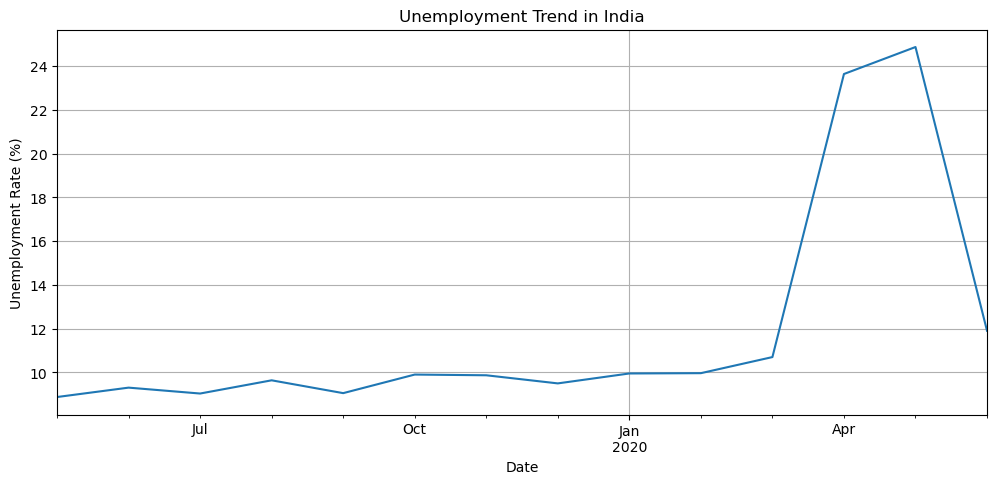

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
df.groupby('Date')['Unemployment_Rate'].mean().plot()
plt.title("Unemployment Trend in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid()
plt.show()

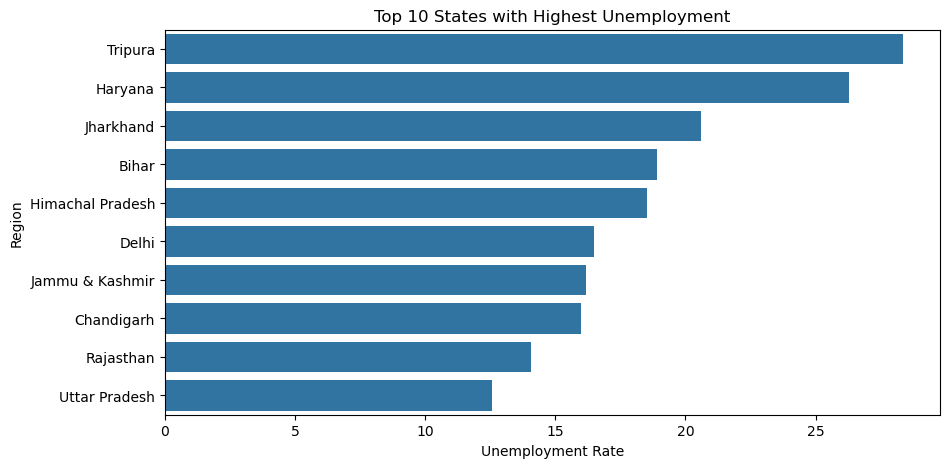

In [20]:
import seaborn as sns

top_states = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top 10 States with Highest Unemployment")
plt.xlabel("Unemployment Rate")
plt.show()

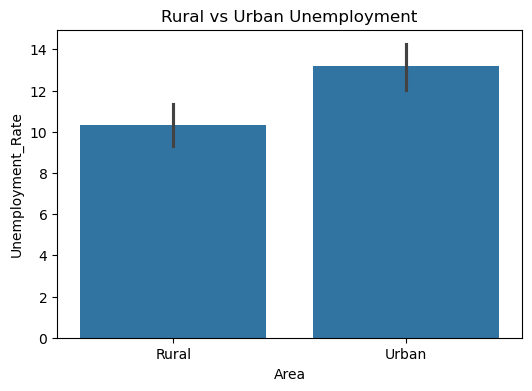

In [21]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Area', y='Unemployment_Rate')
plt.title("Rural vs Urban Unemployment")
plt.show()

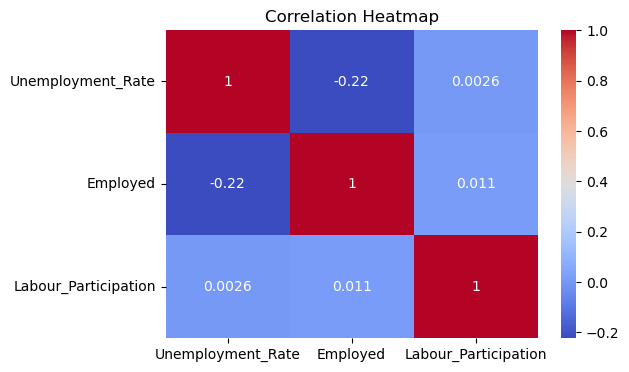

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Unemployment_Rate', 'Employed', 'Labour_Participation']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [23]:
df_covid = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [24]:
df_covid.columns = df_covid.columns.str.strip()

In [25]:
df_covid.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [26]:
df_covid.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [27]:
df_covid['Date'] = pd.to_datetime(df_covid['Date'], dayfirst=True)

In [28]:
df_covid.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation'
}, inplace=True)

In [29]:
df_covid = df_covid.dropna()

In [30]:
df_covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Region                267 non-null    object        
 1   Date                  267 non-null    datetime64[ns]
 2   Frequency             267 non-null    object        
 3   Unemployment_Rate     267 non-null    float64       
 4   Employed              267 non-null    int64         
 5   Labour_Participation  267 non-null    float64       
 6   Region.1              267 non-null    object        
 7   longitude             267 non-null    float64       
 8   latitude              267 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 18.9+ KB


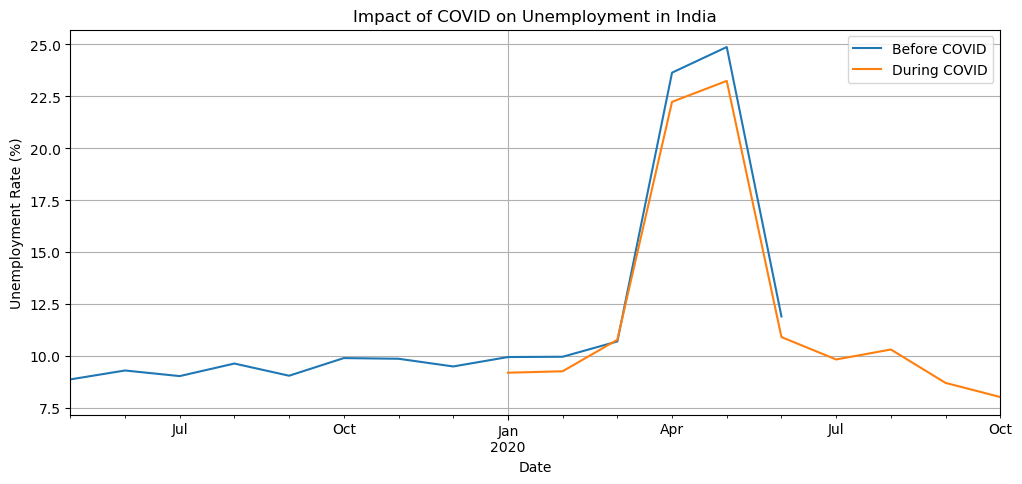

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

df.groupby('Date')['Unemployment_Rate'].mean().plot(label="Before COVID")

df_covid.groupby('Date')['Unemployment_Rate'].mean().plot(label="During COVID")

plt.title("Impact of COVID on Unemployment in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid()
plt.show()

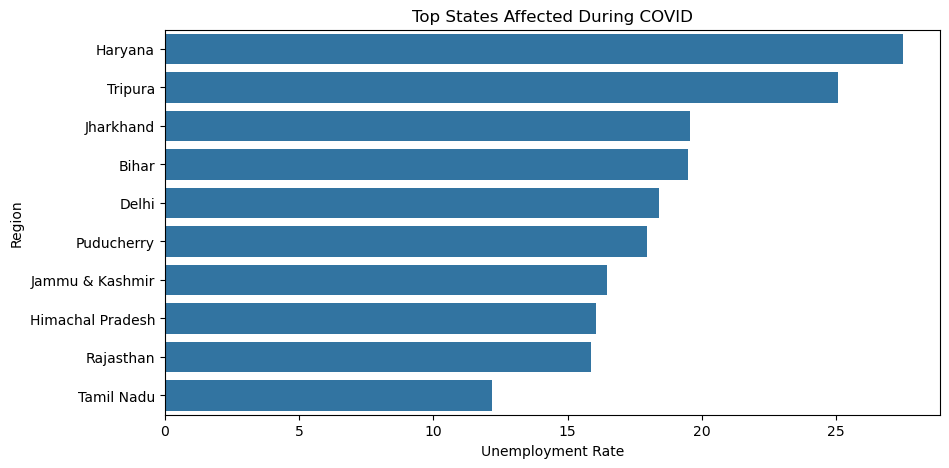

In [32]:
top_states_covid = df_covid.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
import seaborn as sns
sns.barplot(x=top_states_covid.values, y=top_states_covid.index)
plt.title("Top States Affected During COVID")
plt.xlabel("Unemployment Rate")
plt.show()

In [33]:
peak = df_covid.groupby('Date')['Unemployment_Rate'].mean().sort_values(ascending=False)

print("Top 5 Peak Months:\n", peak.head())

Top 5 Peak Months:
 Date
2020-05-31    23.244444
2020-04-30    22.236154
2020-06-30    10.911111
2020-03-31    10.782593
2020-08-31    10.313333
Name: Unemployment_Rate, dtype: float64


In [34]:
before_mean = df['Unemployment_Rate'].mean()
covid_mean = df_covid['Unemployment_Rate'].mean()

print("Before COVID Avg:", before_mean)
print("During COVID Avg:", covid_mean)

Before COVID Avg: 11.787945945945946
During COVID Avg: 12.236928838951311


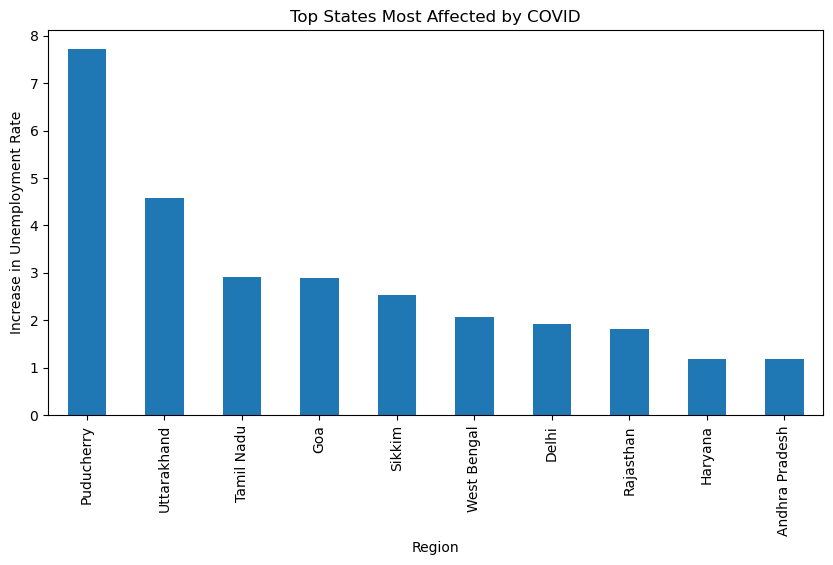

In [35]:
before_state = df.groupby('Region')['Unemployment_Rate'].mean()
covid_state = df_covid.groupby('Region')['Unemployment_Rate'].mean()

comparison = pd.DataFrame({
    'Before_COVID': before_state,
    'During_COVID': covid_state
}).dropna()

comparison['Increase'] = comparison['During_COVID'] - comparison['Before_COVID']

top_affected = comparison.sort_values('Increase', ascending=False).head(10)

import matplotlib.pyplot as plt

top_affected['Increase'].plot(kind='bar', figsize=(10,5), title="Top States Most Affected by COVID")
plt.ylabel("Increase in Unemployment Rate")
plt.show()

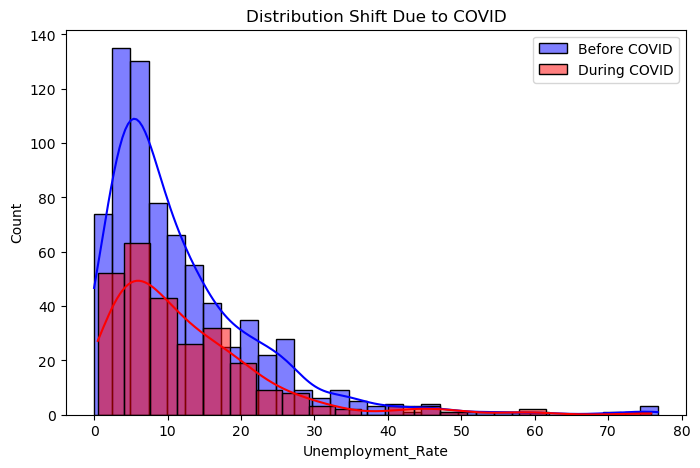

In [36]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Unemployment_Rate'], color='blue', label='Before COVID', kde=True)
sns.histplot(df_covid['Unemployment_Rate'], color='red', label='During COVID', kde=True)
plt.legend()
plt.title("Distribution Shift Due to COVID")
plt.show()

In [38]:
from sklearn.model_selection import train_test_split

X = df[['Employed', 'Labour_Participation']]
y = df['Unemployment_Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.03938840314253944


In [43]:
import joblib

model = joblib.load("unemployment.pkl")